# PPD: eight sequences and Leave-One-Out evaluation

PPD has eight sequence IDs: 7, 8, 9, 11, 13, 14, 15, and 16. The number after C
identifies the sequence; hyphenated suffixes identify ordered source parts.
Loading sequence 7 joins C7-1 followed by C7-2, and loading 13 joins C13-1
followed by C13-2. The other sequences each contain one source file.

Use one complete sequence as the held-out case in each Leave-One-Out fold.
The 25 source signals are retained. RUL can be derived relative to a complete
sequence endpoint for an endpoint-based benchmark; cycle-phase labels are not
supplied in the CSVs.

[Provider and attribution](https://www.kaggle.com/datasets/inIT-OWL/production-plant-data-for-condition-monitoring)
· [Dataset guide](../../pdmdata/ppd/README.md)

Run `pdmdata.download("ppd")` explicitly if needed. This notebook reads local data
and saves Matplotlib output for GitHub; loading never downloads implicitly.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0, str(ROOT))
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
import pdmdata
from pdmdata.ppd import SEQUENCE_IDS, inventory
from pdmdata.ppd.loader import SENSOR_COLUMNS
from pdmdata.ppd.viz import DEFAULT_SIGNALS, plot_waveforms, plot_recordings

files = inventory()
print(f"Sequences: {files.height}; source files: {files['parts'].sum()}; observations: {files['samples'].sum():,}")
print("Raw schema: Timestamp plus 25 process signals; no target columns")
display(files.select("sequence_id", "source_files", "samples", "first_sample", "last_sample",
                     "missing_values", "rows_with_missing", "constant_signals"))


Sequences: 8; source files: 10; observations: 228,424
Raw schema: Timestamp plus 25 process signals; no target columns


sequence_id,source_files,samples,first_sample,last_sample,missing_values,rows_with_missing,constant_signals
i64,list[str],i64,i64,i64,i64,i64,list[null]
7,"[""C7-1.csv"", ""C7-2.csv""]",51671,0,51670,100,4,[]
8,"[""C8.csv""]",15803,0,15802,0,0,[]
9,"[""C9.csv""]",34245,0,34244,0,0,[]
11,"[""C11.csv""]",18429,0,18428,0,0,[]
13,"[""C13-1.csv"", ""C13-2.csv""]",23670,0,23669,0,0,[]
14,"[""C14.csv""]",32848,0,32847,100,4,[]
15,"[""C15.csv""]",30737,0,30736,100,4,[]
16,"[""C16.csv""]",21021,0,21020,0,0,[]


## Time axis and missing measurements

`Timestamp` runs from zero to the row count minus one in each distributed file.
No physical sampling interval is provided in these CSVs, so plots use the source
index rather than seconds or hertz. The loader adds a continuous zero-based
`sample` index across joined parts, preserving the original `Timestamp` resets
and `source_file` for provenance. Dashed lines mark source-part boundaries; no
physical downtime is inferred or filled between parts.

C7-2, C14, and C15 each contain four consecutive rows missing all 25 signals.
Those rows remain in the data, creating visible gaps instead of shifting the
remaining samples. C13-2 also has constant L_3 and L_6 signals.


In [2]:
missing = []
for sequence_id in SEQUENCE_IDS:
    data = pdmdata.load("ppd", sequence_id=sequence_id)
    gaps = data.filter(pl.any_horizontal(pl.col(SENSOR_COLUMNS).is_null()))
    if gaps.height:
        missing.append({"sequence_id": sequence_id, "sample_indices": gaps["sample"].to_list(),
                        "source_indices": gaps["Timestamp"].to_list()})
display(pl.DataFrame(missing))


sequence_id,sample_indices,source_indices
i64,list[i64],list[i64]
7,"[26107, 26108, … 26110]","[9134, 9135, … 9137]"
14,"[18812, 18813, … 18815]","[18812, 18813, … 18815]"
15,"[15914, 15915, … 15917]","[15914, 15915, … 15917]"


## A complete recording with a compact signal selection

The default loads the complete C7 sequence (both source parts). Six channels are selected
for readability across the column families, not as a validated model feature
set. Change SEQUENCE_ID and SIGNALS to inspect any of the 25 source signals.
Values retain the source scale; physical units and detailed channel meanings
are not assigned from anonymized column names.


signal,missing,unique_values,standard_deviation
str,i64,i64,f64
"""L_1""",4,621,39.687322
"""L_2""",4,5970,25.039548
"""L_3""",4,1376,76.597186
"""L_4""",4,2695,83.296698
"""L_5""",4,2687,32.52941
…,…,…,…
"""C_1""",4,225,24.275039
"""C_2""",4,345,29.054252
"""C_3""",4,3345,22.218509


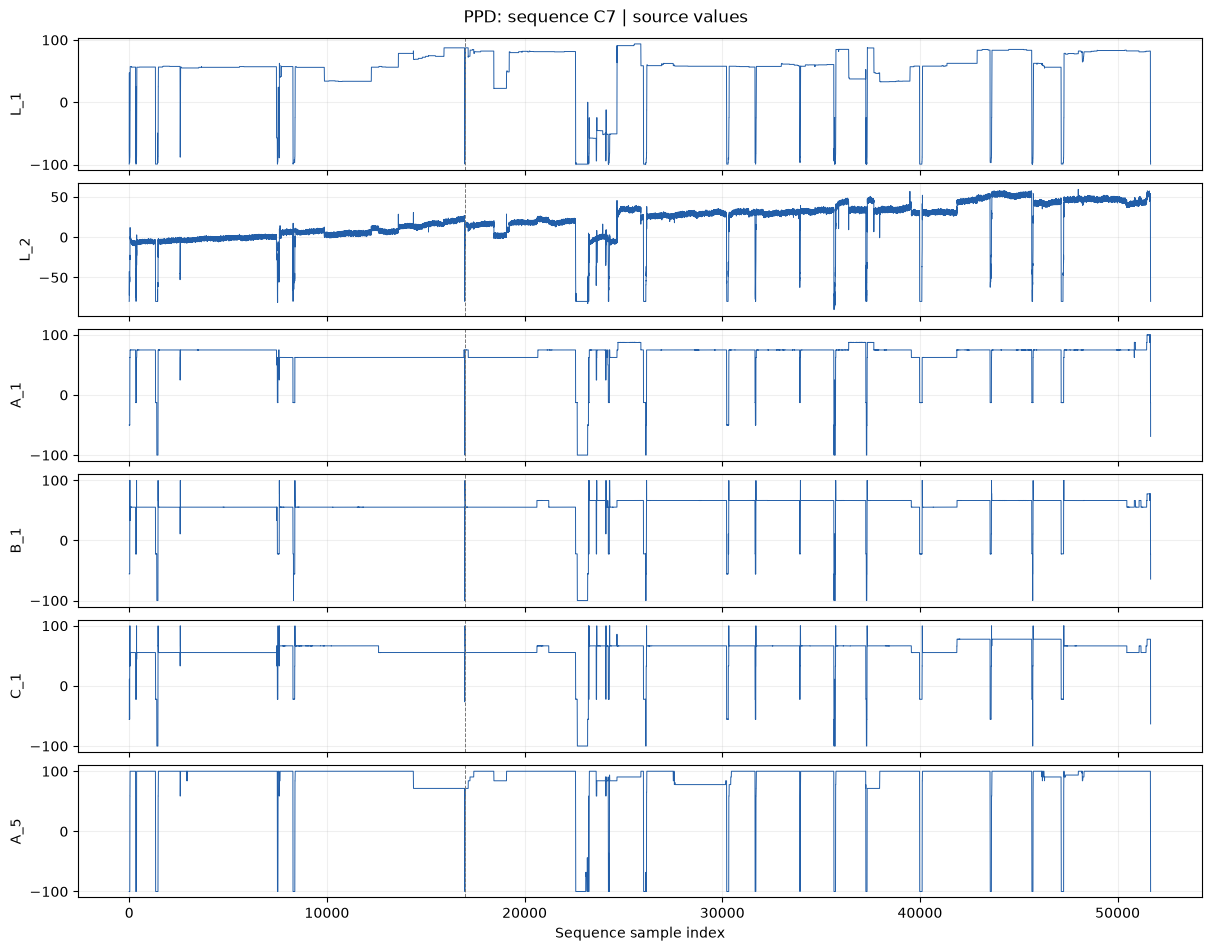

In [3]:
SEQUENCE_ID = 7
SIGNALS = DEFAULT_SIGNALS
frame = pdmdata.load("ppd", sequence_id=SEQUENCE_ID)
display(pl.DataFrame({"signal": SENSOR_COLUMNS,
    "missing": [frame[c].null_count() for c in SENSOR_COLUMNS],
    "unique_values": [frame[c].drop_nulls().n_unique() for c in SENSOR_COLUMNS],
    "standard_deviation": [frame[c].std() for c in SENSOR_COLUMNS]}))
overview = plot_waveforms(frame, columns=SIGNALS)
plt.show()


## Zoom into the first 500 observations

This sample prefix makes shorter changes easier to inspect. No smoothing,
resampling, or inferred state labels are applied. START and STOP select rows.


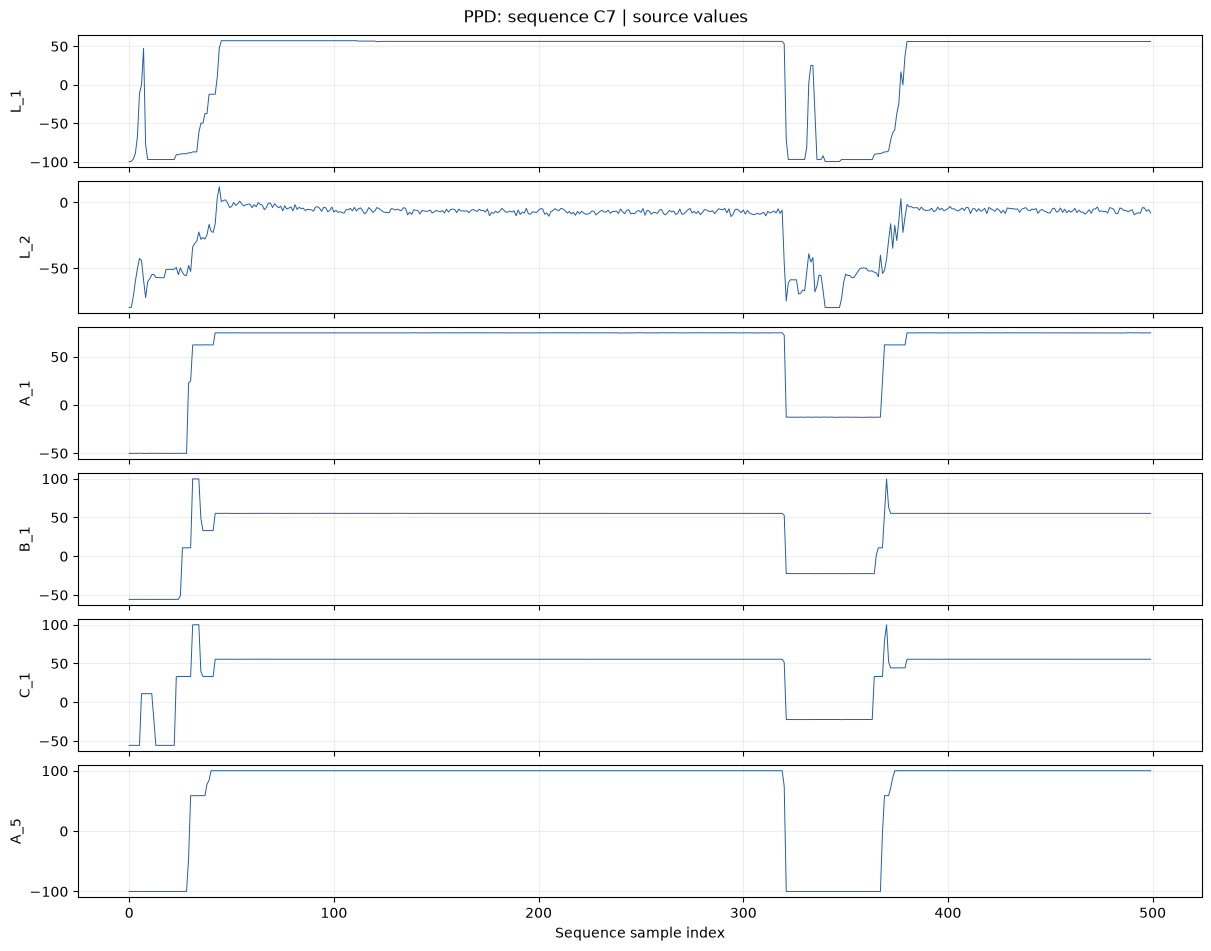

In [4]:
START, STOP = 0, 500
zoom = plot_waveforms(frame, columns=SIGNALS, start=START, stop=STOP)
assets = ROOT / "pdmdata/ppd/assets"
assets.mkdir(parents=True, exist_ok=True)
zoom.savefig(assets / "waveforms.png", dpi=100)
plt.show()


## A real missing-data interval

The gap below comes from missing measurements in C7-2. It is not a labeled
failure or an estimated change point. The original timestamp indices are retained.


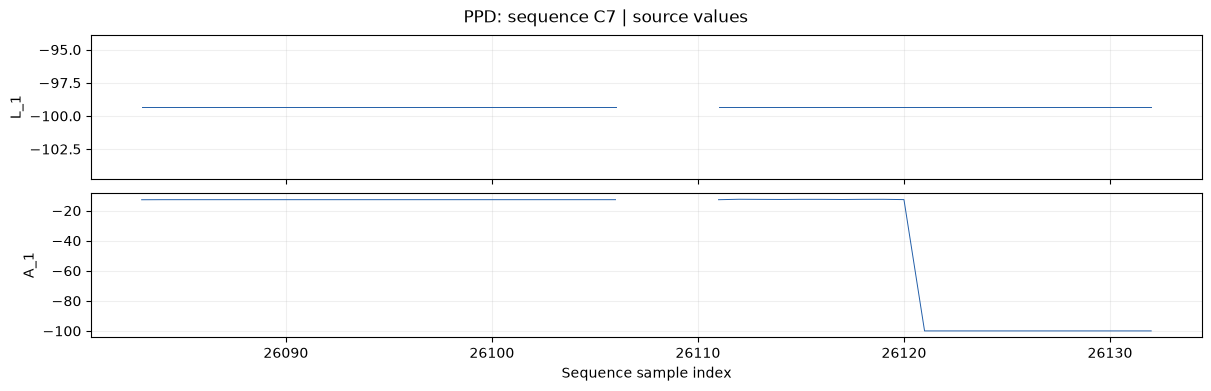

In [5]:
gap_frame = pdmdata.load("ppd", sequence_id=7)
first_missing = gap_frame.filter(pl.any_horizontal(pl.col(SENSOR_COLUMNS).is_null()))["sample"][0]
gap_figure = plot_waveforms(gap_frame, columns=["L_1", "A_1"],
                            start=first_missing - 24, stop=first_missing + 26)
plt.show()


## Compare one prefix per trial

These panels compare the first 1,500 observations of separate experiments with a
shared amplitude scale. Every frame contains a complete sequence; this plot
selects only the prefix for readability.
No continuity, alignment by physical age, or class label is implied.


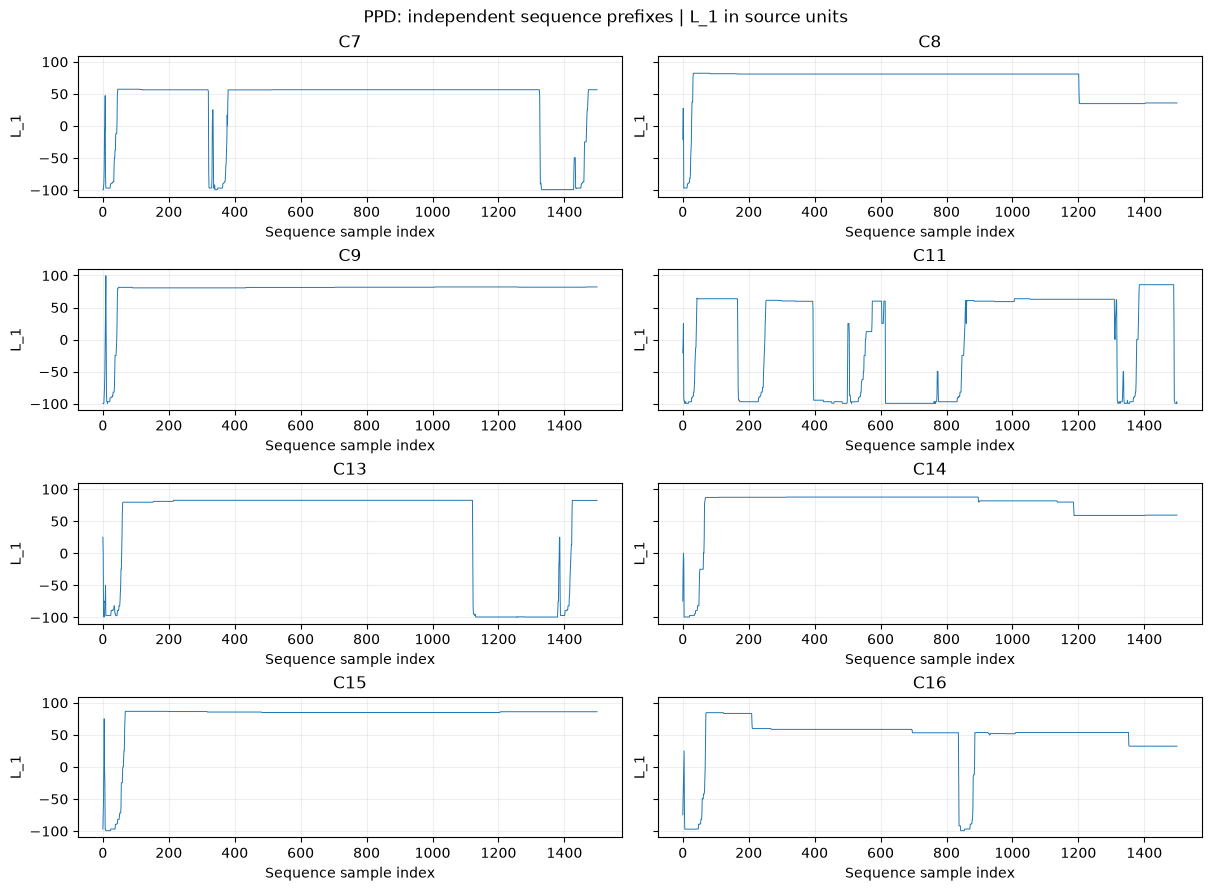

In [6]:
examples = [pdmdata.load("ppd", sequence_id=i) for i in SEQUENCE_IDS]
comparison = plot_recordings(examples, column="L_1", stop=1500)
plt.show()


## Leave-One-Out by sequence

Eight folds hold out one complete sequence each. Both source parts of C7 or C13
always stay in the same fold. Fit scaling and model selection using training
sequences only. This cell demonstrates partitioning; it does not train a model.


In [7]:
sequences = dict(zip(SEQUENCE_IDS, examples))
folds = []
for held_out in SEQUENCE_IDS:
    train_ids = [i for i in SEQUENCE_IDS if i != held_out]
    train = pl.concat([sequences[i] for i in train_ids])
    test = sequences[held_out]
    assert held_out not in train["sequence_id"].unique().to_list()
    folds.append({"test_sequence": held_out, "train_sequences": train_ids,
                  "train_samples": train.height, "test_samples": test.height})
display(pl.DataFrame(folds))


test_sequence,train_sequences,train_samples,test_samples
i64,list[i64],i64,i64
7,"[8, 9, … 16]",176753,51671
8,"[7, 9, … 16]",212621,15803
9,"[7, 8, … 16]",194179,34245
11,"[7, 8, … 16]",209995,18429
13,"[7, 8, … 16]",204754,23670
14,"[7, 8, … 16]",195576,32848
15,"[7, 8, … 16]",197687,30737
16,"[7, 8, … 15]",207403,21021


## Implications for dependency-based segmentation

- PPD supplies 25 signals, yielding 300 possible undirected sensor pairs. A small
  subset can aid interpretation, but choose it using training data and a stated
  rationale rather than selecting the most visually separable channels.
- Inspect constants, missing values, trends, and scale differences before fitting
  covariance or precision matrices. Keep missing stretches out of sliding windows
  or document a training-only imputation procedure.
- The sequence ID is not a within-sequence state label. Supervised boundary or state accuracy
  cannot be calculated from the distributed CSVs alone without an external,
  defensible annotation source.
- For an endpoint-based RUL target, use `sequence.height - 1 - sample` on a
  complete sequence. An intermediate file boundary is not the sequence endpoint.
- Split evaluation by trial, keeping both C7 files together and both C13 files
  together. Avoid overlap leakage from windows of the same trial.
- Compare dependency-based segmentation against mean/variance changes. A visually
  changing waveform does not itself establish a conditional-dependence change.
- Establish the acquisition time base before interpreting window sizes in seconds.

Source: inIT-OWL, *Production Plant Data for Condition Monitoring*, associated
with von Birgelen et al. (2018), *Self-Organizing Maps for Anomaly Localization
and Predictive Maintenance in Cyber-Physical Production Systems*.
Source data and the derived preview: [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).
